# Layer Ablation Study on DistilBERT for IMDb Sentiment Classification

## Objective

The original DistilBERT model has 6 Transformer layers. In this extension, I investigate whether DistilBERT can be compressed even further by reducing the number of layers to 4 and 3 while still maintaining good sentiment classification performance on the IMDb dataset. The performance of the three models will be compared using accuracy, parameter count, model size, and inference speed.

## Install Dependencies

In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

## Import Required Libraries

In [2]:
import sys
import os
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

In [3]:
import os
print(os.getcwd())

/home/jovyan/distilbert-reproduction/distilbert-reproduction/notebooks


In [4]:
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))

In [5]:
def load_module(name, path):
    import importlib.util
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

train_mod  = load_module("train", src_path + "/train.py")
eval_mod   = load_module("model_evaluate", src_path + "/evaluate.py")
utils_mod  = load_module("utils", src_path + "/utils.py")

train_model             = train_mod.train_model
evaluate_model          = eval_mod.evaluate_model
print_model_info        = utils_mod.print_model_info
measure_inference_speed = utils_mod.measure_inference_speed
save_results            = utils_mod.save_results
count_parameters        = utils_mod.count_parameters
model_size_mb           = utils_mod.model_size_mb

2026-06-26 22:37:02.347936: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/micromamba/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/micromamba/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.

## Configure the Experiment
Set the hyperparameters and hardware configuration used throughout the layer ablation study.

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [7]:
MAX_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 2
LR = 2e-5
SEED = 42

## Load IMDb Dataset

In [8]:
raw = load_dataset("imdb")

print(f"Train samples: {len(raw['train'])}")
print(f"Test samples : {len(raw['test'])}")

print("\nFirst review:\n")
print(raw["train"][0]["text"][:300])

Train samples: 25000
Test samples : 25000

First review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


## Create DataLoaders

In [9]:
def get_dataloaders(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
        )

    tokenized = raw.map(tokenize, batched=True)

    cols = ["input_ids", "attention_mask", "label"]

    if "distilbert" not in model_name:
        cols.append("token_type_ids")

    tokenized.set_format("torch", columns=cols)
    tokenized = tokenized.rename_column("label", "labels")

    train_loader = DataLoader(
        tokenized["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    test_loader = DataLoader(
        tokenized["test"],
        batch_size=BATCH_SIZE,
    )

    return train_loader, test_loader

## Create DistilBERT with Fewer Layers

In [10]:
from transformers import AutoConfig

def create_distilbert_model(num_layers):
    """
    Load DistilBERT and keep only the first num_layers Transformer layers.
    """

    # Load the normal DistilBERT model
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2
    )

    # Print the original number of layers
    print("Original layers:", len(model.distilbert.transformer.layer))

    # Keep only the first num_layers layers
    model.distilbert.transformer.layer = torch.nn.ModuleList(
        model.distilbert.transformer.layer[:num_layers]
    )

    # Print the new number of layers
    print("New layers:", len(model.distilbert.transformer.layer))

    return model

## Define the Training Pipeline
The same training and evaluation pipeline is used for all models to ensure a fair comparison.

In [11]:
def run_extension_pipeline(model, model_name):

    print("=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)


    print_model_info(model, model_name)

    history = train_model(
        model,
        train_loader,
        test_loader,
        DEVICE,
        epochs=EPOCHS,
        lr=LR,
    )

    eval_results = evaluate_model(model, test_loader, DEVICE)

    speed = measure_inference_speed(model, test_loader, DEVICE)

    total_params, _ = count_parameters(model)

    results = {
        "model": model_name,
        "accuracy": eval_results["accuracy"],
        "parameters": total_params,
        "model_size_mb": model_size_mb(model),
        "speed": speed,
        "history": history,
    }

    return results

## Create the DataLoaders

The IMDb dataset is tokenized and converted into PyTorch DataLoaders once so that the same training and test data can be reused for all layer ablation experiments.

In [12]:
train_loader, test_loader = get_dataloaders("distilbert-base-uncased")

print("Data loaders created successfully.")

Data loaders created successfully.


## Train the Original DistilBERT (6 Layers)

The original 6-layer DistilBERT model is trained first to provide a baseline for comparison with the smaller models.

In [13]:
baseline_model = create_distilbert_model(6)

baseline_results = run_extension_pipeline(
    baseline_model,
    "DistilBERT (6 layers)"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original layers: 6
New layers: 6
Training: DistilBERT (6 layers)
DistilBERT (6 layers)
  Total parameters:     66,955,010
  Trainable parameters: 66,955,010
  Estimated size:       255.41 MB


Epoch 1/2 [val]: 100%|██████████| 1563/1563 [01:30<00:00, 17.32it/s]


Epoch 1: loss=0.2920, val_acc=92.98%


Epoch 2/2 [val]: 100%|██████████| 1563/1563 [01:30<00:00, 17.33it/s]


Epoch 2: loss=0.1509, val_acc=93.21%


Evaluating: 100%|██████████| 1563/1563 [01:30<00:00, 17.34it/s]


## Train the 4-Layer DistilBERT

The first layer ablation experiment reduces the model from six Transformer layers to four layers.

In [14]:
model4 = create_distilbert_model(4)

results4 = run_extension_pipeline(
    model4,
    "DistilBERT (4 layers)"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original layers: 6
New layers: 4
Training: DistilBERT (4 layers)
DistilBERT (4 layers)
  Total parameters:     52,779,266
  Trainable parameters: 52,779,266
  Estimated size:       201.34 MB


Epoch 1/2 [val]: 100%|██████████| 1563/1563 [01:00<00:00, 25.72it/s]


Epoch 1: loss=0.3470, val_acc=91.05%


Epoch 2/2 [val]: 100%|██████████| 1563/1563 [01:00<00:00, 25.70it/s]


Epoch 2: loss=0.1863, val_acc=91.99%


Evaluating: 100%|██████████| 1563/1563 [01:00<00:00, 25.68it/s]


## Train the 3-Layer DistilBERT

The second layer ablation experiment further reduces the model to three Transformer layers.

In [15]:
model3 = create_distilbert_model(3)

results3 = run_extension_pipeline(
    model3,
    "DistilBERT (3 layers)"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Original layers: 6
New layers: 3
Training: DistilBERT (3 layers)
DistilBERT (3 layers)
  Total parameters:     45,691,394
  Trainable parameters: 45,691,394
  Estimated size:       174.3 MB


Epoch 1/2 [val]: 100%|██████████| 1563/1563 [00:46<00:00, 33.87it/s]


Epoch 1: loss=0.3624, val_acc=89.43%


Epoch 2/2 [val]: 100%|██████████| 1563/1563 [00:46<00:00, 33.85it/s]


Epoch 2: loss=0.2069, val_acc=91.01%


Evaluating: 100%|██████████| 1563/1563 [00:46<00:00, 33.82it/s]


## Compare the Experimental Results

The three DistilBERT models are compared using classification accuracy, parameter count, model size, and inference speed.

In [16]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Layers": 6,
        "Accuracy (%)": baseline_results["accuracy"],
        "Parameters (Millions)": round(baseline_results["parameters"] / 1_000_000, 2),
        "Model Size (MB)": baseline_results["model_size_mb"],
        "Inference Speed (Samples/sec)": baseline_results["speed"]["samples_per_second"],
    },
    {
        "Layers": 4,
        "Accuracy (%)": results4["accuracy"],
        "Parameters (Millions)": round(results4["parameters"] / 1_000_000, 2),
        "Model Size (MB)": results4["model_size_mb"],
        "Inference Speed (Samples/sec)": results4["speed"]["samples_per_second"],
    },
    {
        "Layers": 3,
        "Accuracy (%)": results3["accuracy"],
        "Parameters (Millions)": round(results3["parameters"] / 1_000_000, 2),
        "Model Size (MB)": results3["model_size_mb"],
        "Inference Speed (Samples/sec)": results3["speed"]["samples_per_second"],
    }
])

comparison

,Layers,Accuracy (%),Parameters (Millions),Model Size (MB),Inference Speed (Samples/sec)
0,6,93.21,66.96,255.41,5040.17
1,4,91.99,52.78,201.34,6734.70
2,3,91.01,45.69,174.30,8227.86


## Save the Results

The comparison table is saved as a CSV file for later analysis and reporting.

In [17]:
comparison.to_csv("../results/layer_ablation_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


## Visualize the Results
The following figures visualize the effect of reducing the number of Transformer layers on accuracy, model size and parameter count.

## Accuracy Comparison

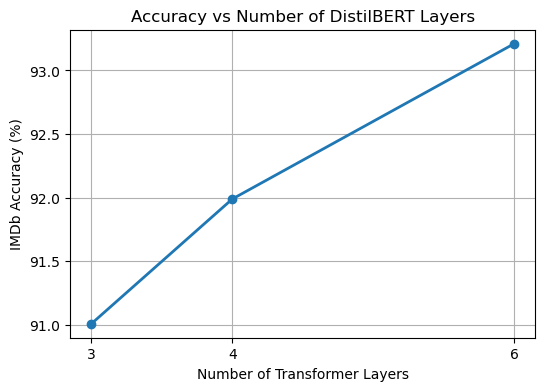

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    comparison["Layers"],
    comparison["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.xticks([3,4,6])
plt.xlabel("Number of Transformer Layers")
plt.ylabel("IMDb Accuracy (%)")
plt.title("Accuracy vs Number of DistilBERT Layers")
plt.grid(True)

plt.show()

## Model Size Comparison

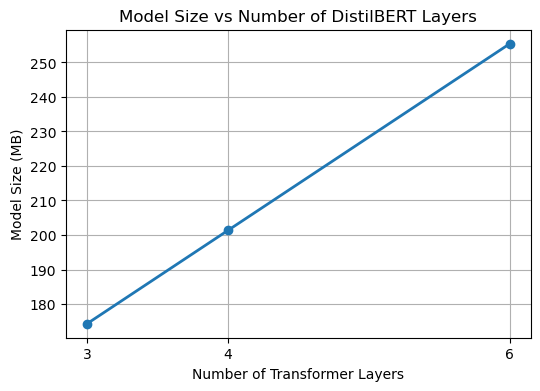

In [19]:
plt.figure(figsize=(6,4))

plt.plot(
    comparison["Layers"],
    comparison["Model Size (MB)"],
    marker="o",
    linewidth=2
)

plt.xticks([3,4,6])
plt.xlabel("Number of Transformer Layers")
plt.ylabel("Model Size (MB)")
plt.title("Model Size vs Number of DistilBERT Layers")
plt.grid(True)

plt.show()

## Parameter Comparison

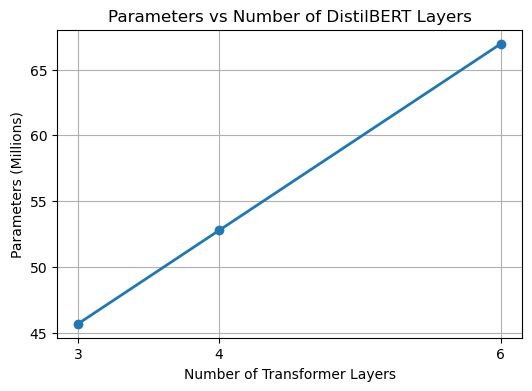

In [20]:
plt.figure(figsize=(6,4))

plt.plot(
    comparison["Layers"],
    comparison["Parameters (Millions)"],
    marker="o",
    linewidth=2
)

plt.xticks([3,4,6])
plt.xlabel("Number of Transformer Layers")
plt.ylabel("Parameters (Millions)")
plt.title("Parameters vs Number of DistilBERT Layers")
plt.grid(True)

plt.show()

## Export Results as JSON
The comparison results are also exported in JSON format for consistency with the rest of the project.

In [21]:
comparison.to_json(
    "../results/layer_ablation_results.json",
    orient="records",
    indent=4
)

print("JSON file saved successfully.")

JSON file saved successfully.


In [22]:
print("="*70)
print("Layer Ablation Study Results")
print("="*70)

print(comparison.to_string(index=False))

Layer Ablation Study Results
 Layers  Accuracy (%)  Parameters (Millions)  Model Size (MB)  Inference Speed (Samples/sec)
      6         93.21                  66.96           255.41                        5040.17
      4         91.99                  52.78           201.34                        6734.70
      3         91.01                  45.69           174.30                        8227.86


## Save Individual Experiment Results

Each experiment is saved separately in JSON format so that the results can be reused in the comparison notebook.

In [23]:
save_results(baseline_results, "layer6_results.json")
save_results(results4, "layer4_results.json")
save_results(results3, "layer3_results.json")

Results saved to ../results/layer6_results.json
Results saved to ../results/layer4_results.json
Results saved to ../results/layer3_results.json


## Discussion
The original 6-layer DistilBERT achieved an accuracy of 93.21% with 66.96 million parameters and a model size of 255.41 MB. Reducing the model to 4 layers decreased the model size to 201.34 MB while maintaining an accuracy of 91.99%. The 3-layer model further reduced the model size to 174.30 MB and the number of parameters to 45.69 million, but the accuracy decreased to 91.01%. The inference speed also improved as the number of layers decreased, increasing from 5040.17 samples per second for the 6-layer model to 8227.86 samples per second for the 3-layer model. These results demonstrate that reducing the number of Transformer layers improves computational efficiency while gradually reducing predictive performance.

## Conclusion
In this extension, I investigated the effect of reducing the number of Transformer layers in DistilBERT for IMDb sentiment classification. Starting from the original 6-layer model, I created smaller versions with 4 and 3 layers and compared their performance.

The experiments showed that the 4-layer model reduced the number of parameters and model size while maintaining accuracy close to the original DistilBERT. The 3-layer model achieved additional compression and faster inference but with a larger reduction in accuracy.

Overall, the results indicate that a moderate reduction in the number of Transformer layers provides a good balance between efficiency and performance, making smaller DistilBERT models suitable for environments with limited computational resources.

## Summary

In this extension, I evaluated the effect of reducing the number of Transformer layers in DistilBERT for IMDb sentiment classification. The experiments showed that reducing the model from six to four layers significantly reduced the number of parameters and model size while maintaining competitive accuracy. Reducing the model further to three layers provided additional model compression and faster inference, but resulted in a larger decrease in accuracy. Overall, the results demonstrate the trade-off between model efficiency and predictive performance.